## Run inference
### Using TorchIO to replace the standard pytorch dataloader and the custom patch-processor. 

In [42]:
import torch
import torchio as tio
import os
import numpy as np
from skimage import io
import sys 
import yaml
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from models import networks
from models import create_model



### Set the parameters for the inference 

In [33]:
yaml_file = '../configs/kaarjel-inference-config-20250317-1.yaml'
with open(yaml_file, "r") as f:
    yaml_config = yaml.safe_load(f)

In [34]:
class DummpyOptions():
    def __init__(self):

        self.initialized = False
    
    def gather_options(self, yaml_config):
        
        recursive_attr(self, yaml_config)
        return self
    
@staticmethod
def recursive_attr(class_instance, dict_):
    '''
    If YAML file contains a nested dictionary, this function will iterate to the deepest depth to parse all configs
    '''
    for k, v in dict_.items():
        if isinstance(v, dict):
            new_dict =  dict(zip(v.keys(), v.values()))
            recursive_attr(class_instance, new_dict)
        else:
            setattr(class_instance, k, v)


In [43]:
opt = DummpyOptions()
opt.gather_options(yaml_config)

model = create_model(opt)  # create a model given opt.model and other options
model.setup(opt) 

initialize network with kaiming
model [TestModel] was created
loading the model from /scratch/park/checkpoints/models/DeepClarity/kaarjel-1st-confocal-to-STED-Sif_exp_250312-163425/iter_97500_net_G_A.pth
---------- Networks initialized -------------
[Network G_A] Total number of parameters : 7.077 M
-----------------------------------------------


/g/kreshuk/park/code/neuroclear/models/base_model.py:199: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(load_path, map_location=str(self.device))


In [40]:
print (opt.__dict__)

{'initialized': False, 'device': 'cuda', 'name': 'kaarjel-1st-confocal-to-STED-Sif_exp_250312-163425', 'load_iter': 97500, 'phase': 'test', 'checkpoints_dir': '/scratch/park/checkpoints/models/DeepClarity', 'results_dir': '/scratch/park/results/DeepClarity', 'skip_real': True, 'verbose': False, 'save_volume': True, 'eval': True, 'batch_size': 1, 'gpu_ids': [0], 'preprocess': 'addColorChannel', 'border_cut': 20, 'dice_size': 140, 'overlap': 15, 'data_type': 'uint16', 'histogram_match': False, 'normalize_intensity': False, 'sat_level': [0.25, 99.75], 'data_source': '/scratch/park/data/Koehler/Oane', 'image_dimension': 3, 'direction': 'AtoB', 'serial_batches': False, 'model': 'test', 'model_suffix': '_A', 'input_nc': 1, 'output_nc': 1, 'ngf': 64, 'netG': 'unet_deconv', 'norm': 'instance_with_trackstats', 'init_type': 'kaiming', 'init_gain': 0.02, 'no_dropout': False, 'isTrain': False, 'lr': 0.0001, 'beta1': 0.1, 'momentum': 0.9, 'lr_policy': 'constant', 'save_epoch_freq': 1, 'display_freq

In [2]:
data_source_folder = '/scratch/park/data/Kaarjel/1st_training/confocal'
data_target_folder = '/scratch/park/data/Kaarjel/1st_training/STED'

In [3]:
import os

# Fetch all 'tif' images in the data_source_folder
tif_images_source = [os.path.join(data_source_folder, f) for f in os.listdir(data_source_folder) if f.endswith('.tif')]
print(tif_images_source)
print(f"image # from source: {len(tif_images_source)}")

tif_images_target = [os.path.join(data_target_folder, f) for f in os.listdir(data_target_folder) if f.endswith('.tif')]
print(tif_images_target)
print(f"image # from target: {len(tif_images_target)}")

['/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_7E-01-Airyscan Processing-03.czi - 241206_cryoNUP_SD-C_7E-01-Airyscan Processing-03.czi #3 - C=0-1_voxel0pt1_crop-1.tif', '/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_3E-01-Airyscan Processing-10.czi - C=0_voxel0pt1-normd.tif', '/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_7D-01-Airyscan Processing-07.czi - C=0_voxel0pt1_crop-1.tif', '/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_4F-01-Airyscan Processing-01.czi - 241206_cryoNUP_SD-C_4F-01-Airyscan Processing-01.czi #2 - C=0_voxel0pt1_crop-1.tif', '/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_4F-02-Airyscan Processing-02.czi - C=0_voxel0pt1_crop-1.tif', '/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_7E-01-Airyscan Processing-03.czi - 241206_cryoNUP_SD-C_7E-01-Airyscan Processing-03.czi #2 - C=0-1_voxel0pt1_crop-1.tif', '/scratch/park/data/Kaarjel/1s

In [16]:
test_source_img_raw = io.imread(tif_images_source[0])
test_target_img_raw= io.imread(tif_images_target[0])

test_source_img = np.transpose(test_source_img_raw, axes=(2, 1, 0))
test_target_img = np.transpose(test_target_img_raw, axes=(2, 1, 0))

# Add an extra dimension to the tensors
test_source_img = torch.unsqueeze(torch.tensor(test_source_img), 0)
test_target_img = torch.unsqueeze(torch.tensor(test_target_img), 0)
print(test_source_img.shape)

torch.Size([1, 340, 410, 50])


### Note: TorchIO handles the dimension as in reverse: (C, W, H, D) or (C, X, Y, Z). 

In [5]:
subject_source = tio.Subject(
    image=tio.ScalarImage(tensor=test_source_img),
)
patch_size = 120, 120, 25 # x, y, z 
patch_overlap = 20

In [6]:
grid_sampler = tio.inference.GridSampler(subject_source, patch_size, patch_overlap)
patch_loader = tio.SubjectsLoader(grid_sampler, batch_size=1)
aggregator = tio.inference.GridAggregator(grid_sampler)

In [7]:
len(patch_loader)

96

In [8]:
grid_sampler[0].image['data'].shape

torch.Size([1, 120, 120, 25])

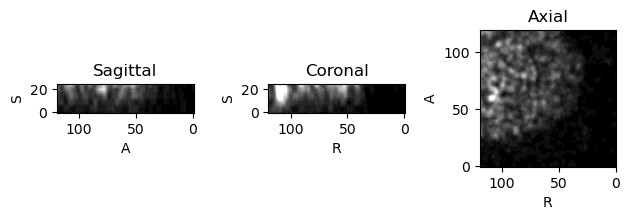

In [28]:
grid_sampler[0].image.plot()

In [ ]:
# # Load the model
# model_path = '/scratch/park/checkpoints/models/DeepClarity/kaarjel-1st-confocal-to-STED-Sif_exp_250312-163425/' 
# model_file= os.path.join(model_path, 'iter_97500_net_G_A.pth')
# loaded_model_weights = torch.load(model_file)


# netG = networks.define_G(1, 1, 64, 'unet_deconv',
#                                 'instance_with_trackstats', not False, opt.init_type, opt.init_gain, [gpu_ids], dimension = self.dimension)


# # loaded_model.eval()  # Set the model to evaluation mode

/tmp/ipykernel_20799/2583220551.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model = torch.load(model_file)


In [45]:
netG = model.netG

In [46]:
netG

Unet_deconv(
  (double_conv1): double_conv(
    (convolution): Sequential(
      (0): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
      (2): ReLU()
      (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
      (5): ReLU()
    )
  )
  (maxpool1): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (double_conv2): double_conv(
    (convolution): Sequential(
      (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): InstanceNorm3d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
      (2): ReLU()
      (3): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): InstanceNorm3d(128, eps=1e-05, momentum=0.1, affine=False, track_ru

In [47]:


# Iterate over the patches and place them back into the reconstructed volume
with torch.no_grad():
    for patch in patch_loader:
        patch_data = patch['image'][tio.DATA] # (B, C, H, W, D)
        patch_data = patch_data.permute(0, 1, 4, 2, 3) # (B, C, D, H, W)
        output = netG(patch_data)
        output = output.permute(0, 1, 3, 4, 2) # (B, C, H, W, D)
        aggregator.add_batch(output, patch[tio.LOCATION])

        # print(patch_data.shape)

RuntimeError: Input type (short unsigned int) and bias type (float) should be the same

In [15]:
output.shape

torch.Size([1, 1, 120, 120, 25])

In [14]:
patch_data.shape

torch.Size([1, 1, 25, 120, 120])

In [12]:
output_tensor = aggregator.get_output_tensor()

In [13]:
output_tensor.shape

torch.Size([1, 340, 410, 50])

In [21]:
output_np.shape

(340, 410, 50)

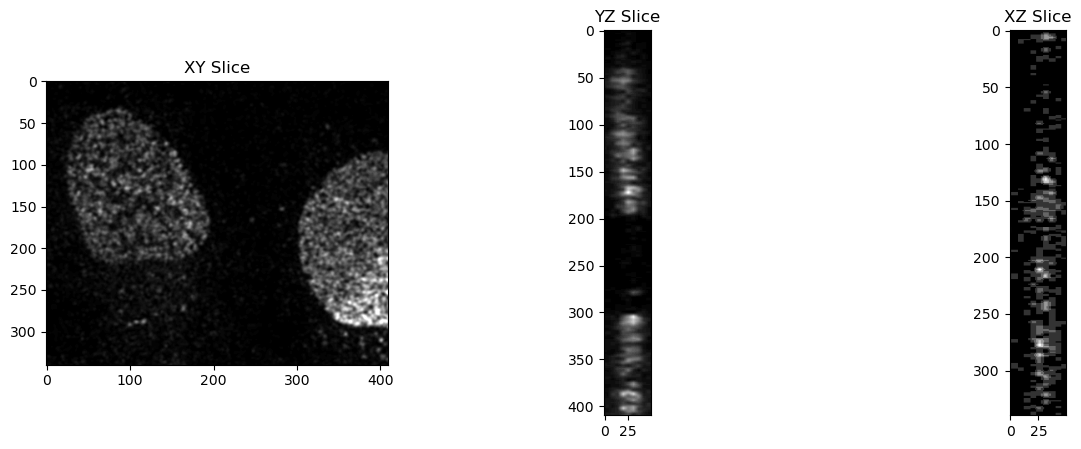

In [22]:
import matplotlib.pyplot as plt

# Convert the tensor to numpy array for visualization
output_np = output_tensor.numpy().squeeze()

# Define the slices to visualize
xy_slice = output_np[:, :, output_np.shape[2] // 2]
yz_slice = output_np[output_np.shape[0] // 2, :, :]
xz_slice = output_np[:, output_np.shape[1] // 2, :]

# Plot the slices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(xy_slice, cmap='gray')
axes[0].set_title('XY Slice')

axes[1].imshow(yz_slice, cmap='gray')
axes[1].set_title('YZ Slice')

axes[2].imshow(xz_slice, cmap='gray')
axes[2].set_title('XZ Slice')

plt.show()

In [ ]:
subject_source.add_image(tio.ScalarImage(tensor=test_source_img), 'reconstructed_image')

In [ ]:
subject_source['image'].plot()
subject_source['reconstructed_image'].plot()